# 02 - Evaluation Dataset

Questo notebook mostra la metodologia dello step 02: normalizzare i CSV sorgenti, validare l'allineamento MCQ/no-hint e produrre artifact pronti per gli step di valutazione.

In [1]:
from __future__ import annotations

import csv
import json
import sys
import tempfile
from pathlib import Path

import matplotlib.pyplot as plt

ROOT = Path.cwd().resolve()
while not (ROOT / "pyproject.toml").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent

SRC = ROOT / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

from legal_rag.evaluation_dataset import EvaluationDatasetConfig, run_evaluation_dataset


def read_jsonl(path: Path) -> list[dict]:
    return [json.loads(line) for line in path.read_text(encoding="utf-8").splitlines() if line.strip()]


def write_csv(path: Path, rows: list[dict[str, str]], fieldnames: list[str]) -> None:
    with path.open("w", encoding="utf-8", newline="") as handle:
        writer = csv.DictWriter(handle, fieldnames=fieldnames)
        writer.writeheader()
        writer.writerows(rows)


## Run simulato

La simulazione usa CSV temporanei piccoli: due record validi e una riga MCQ vuota. Serve a vedere il comportamento della pipeline senza toccare il dataset reale.

In [3]:
mcq_question = "\n".join(
    [
        "Quale requisito deve essere rispettato?",
        "A) Primo requisito",
        "B) Secondo requisito",
        "C) Terzo requisito",
        "D) Quarto requisito",
        "E) Quinto requisito",
        "F) Sesto requisito",
    ]
)

with tempfile.TemporaryDirectory() as tmp:
    tmp_dir = Path(tmp)
    mcq_source = tmp_dir / "questions.csv"
    no_hint_source = tmp_dir / "questions_no_hint.csv"
    output_dir = tmp_dir / "evaluation_clean"

    mcq_fields = ["#", "Domanda", "Livello", "Risposta corretta", "Riferimento legge per la risposta"]
    no_hint_fields = ["Domanda", "Livello", "Risposta corretta", "Riferimento legge per la risposta"]
    write_csv(
        mcq_source,
        [
            {"#": "1", "Domanda": mcq_question, "Livello": "L1", "Risposta corretta": "A", "Riferimento legge per la risposta": "Legge A - Art. 1"},
            {"#": "2", "Domanda": mcq_question.replace("requisito", "vincolo"), "Livello": "L2", "Risposta corretta": "B", "Riferimento legge per la risposta": "Legge B - Art. 2"},
            {"#": "3", "Domanda": "", "Livello": "", "Risposta corretta": "", "Riferimento legge per la risposta": ""},
        ],
        mcq_fields,
    )
    write_csv(
        no_hint_source,
        [
            {"Domanda": "Quale requisito deve essere rispettato?", "Livello": "L1", "Risposta corretta": "Primo requisito", "Riferimento legge per la risposta": "Legge A - Art. 1"},
            {"Domanda": "Quale vincolo deve essere rispettato?", "Livello": "L2", "Risposta corretta": "Secondo vincolo", "Riferimento legge per la risposta": "Legge B - Art. 2"},
        ],
        no_hint_fields,
    )

    simulated_manifest = run_evaluation_dataset(
        EvaluationDatasetConfig(
            mcq_source=str(mcq_source),
            no_hint_source=str(no_hint_source),
            output_dir=str(output_dir),
            expected_records=2,
        )
    )
    simulated_mcq = read_jsonl(output_dir / "questions_mcq.jsonl")

print(json.dumps(simulated_manifest["counts"], ensure_ascii=False, indent=2))
print(json.dumps(simulated_mcq[0], ensure_ascii=False, indent=2))


{
  "mcq": 2,
  "no_hint": 2,
  "mcq_source_rows": 3,
  "no_hint_source_rows": 2,
  "mcq_dropped_empty_rows": 1,
  "no_hint_dropped_empty_rows": 0
}
{
  "correct_answer": "Primo requisito",
  "correct_label": "A",
  "expected_references": [
    "Legge A - Art. 1"
  ],
  "level": "L1",
  "options": {
    "A": "Primo requisito",
    "B": "Secondo requisito",
    "C": "Terzo requisito",
    "D": "Quarto requisito",
    "E": "Quinto requisito",
    "F": "Sesto requisito"
  },
  "qid": "eval-0001",
  "question_stem": "Quale requisito deve essere rispettato?",
  "source_position": 1
}


## Run completo

Questa cella esegue la pipeline sul dataset versionato e rigenera `data/evaluation_clean/`.

In [4]:
config = EvaluationDatasetConfig(
    mcq_source=str(ROOT / "data/evaluation/questions.csv"),
    no_hint_source=str(ROOT / "data/evaluation/questions_no_hint.csv"),
    output_dir=str(ROOT / "data/evaluation_clean"),
)
manifest = run_evaluation_dataset(config)
output_dir = Path(config.output_dir)
profile = json.loads((output_dir / "evaluation_profile.json").read_text(encoding="utf-8"))
quality_report = (output_dir / "quality_report.md").read_text(encoding="utf-8")
mcq_records = read_jsonl(output_dir / "questions_mcq.jsonl")
no_hint_records = read_jsonl(output_dir / "questions_no_hint.jsonl")

print(json.dumps({"ready_for_evaluation": manifest["ready_for_evaluation"], "counts": manifest["counts"]}, ensure_ascii=False, indent=2))


{
  "ready_for_evaluation": true,
  "counts": {
    "mcq": 100,
    "no_hint": 100,
    "mcq_source_rows": 163,
    "no_hint_source_rows": 100,
    "mcq_dropped_empty_rows": 63,
    "no_hint_dropped_empty_rows": 0
  }
}


## Diagnostica visiva

I grafici rendono espliciti il filtro sulle righe sorgenti, il bilanciamento dei livelli e lo stato dei quality gate.

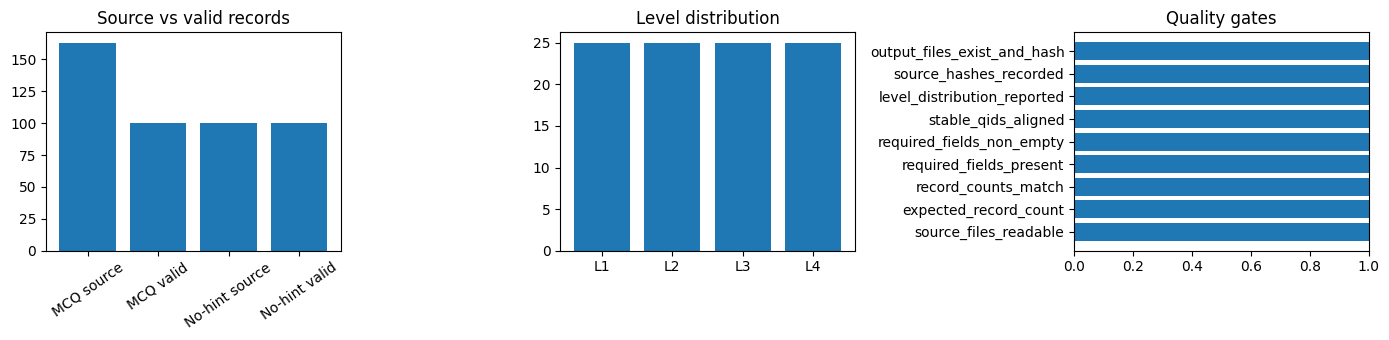

In [5]:
counts = manifest["counts"]
fig, axes = plt.subplots(1, 3, figsize=(14, 3.5))

axes[0].bar(["MCQ source", "MCQ valid", "No-hint source", "No-hint valid"], [counts["mcq_source_rows"], counts["mcq"], counts["no_hint_source_rows"], counts["no_hint"]])
axes[0].set_title("Source vs valid records")
axes[0].tick_params(axis="x", rotation=35)

levels = dict(sorted(manifest["level_distribution"].items()))
axes[1].bar(levels.keys(), levels.values())
axes[1].set_title("Level distribution")

gates = manifest["quality_gates"]
axes[2].barh(list(gates.keys()), [1 if ok else 0 for ok in gates.values()])
axes[2].set_xlim(0, 1)
axes[2].set_title("Quality gates")

plt.tight_layout()
plt.show()


## Esempi normalizzati

Gli esempi mostrano che MCQ e no-hint condividono `qid`, intento, livello, risposta corretta e riferimenti attesi.

In [ ]:
for item in profile["alignment_examples"][:3]:
    print(json.dumps(item, ensure_ascii=False, indent=2))

print("\nSample references:")
for reference in profile["sample_references"][:8]:
    print("-", reference)


## Report di qualita

Il report testuale e lo stesso artifact prodotto dalla pipeline per ispezione rapida e tracciabilita.

In [ ]:
print(quality_report)
